# An OU approximation for fBm with $H < \frac12$

----------------------------------------------------------------------------
In this notebook we implement and validate an the OU approximation of fBm using a geometric discretization of the Muravlev rperesntation


# Simple Simulation of the OU process

So for the standard OU process used in our report we have the transition probability being exactly $$Z_t^{\beta} | Z_s^{\beta} = N \left ( e^{- \beta (t -s)Z_s^{\beta}}, \frac{1 - e^{-2 \beta(t-s)}}{2 \beta} \right ) $$
 So we use the exact discretization:
 $$Z_{t + \Delta t} = e^{- \beta \Delta t}Z_t + \frac{1 - e^{-2 \beta(\Delta t)}}{2 \beta} W$$
 where $ W \sim N(0,1)$

 We can start the process at $Z_0 = 0$..

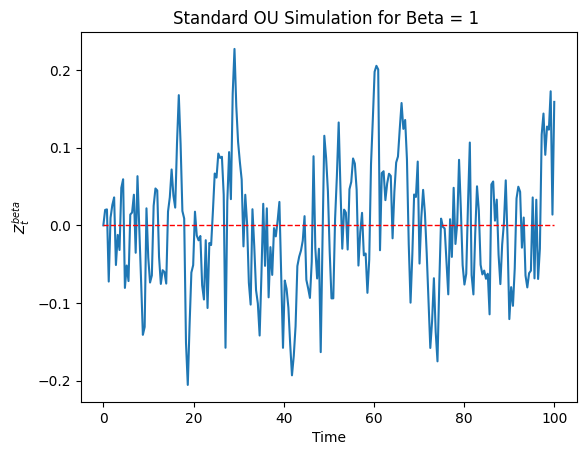

In [1]:
import numpy as np
import matplotlib.pyplot as plt

n = 252
t = 100
dt = t/n
times = np.linspace(0, t, n)
beta = 1

W = np.random.normal(0, dt, n)


Z = np.zeros(n)
Z[0] = 0 # start at z_0 = 0 which can be changed to start from any point
for i in range(1, n):
    Z[i] = np.exp(-beta * dt) * Z[i-1] + (1 - np.exp(-beta * dt))/ (2* beta) * W[i]
    

plt.plot(times, Z)
plt.title(f"Standard OU Simulation for Beta = {beta} ")
plt.hlines(0, color='r', linestyle='--', linewidth=1, xmin=0, xmax=t)
plt.xlabel("Time")
plt.ylabel("$Z^{beta}_t$")
plt.show()

# A More General OU Simulation

We will next generalise the above simulation in two ways.

- First of all we will remove the assmuption that it starts at the origin and have it start at $-\infty$ to make the process stationary.

- Next we will be simulating $n$ correlated OU processes - this is what we will later need for fBm. To do this we account for $Z_0^{\beta_i} = \int_{-\infty}^0 e^{\beta_i u} dB_u$ for each $i = 1 , \dots, n$. Note that each $Z_0^{\beta_i} \sim N(0, \frac1{2 \beta_i})$ with $cov(Z_0^{\beta_i}, Z_0^{\beta_j}) = \frac1{\beta_i + \beta_j}$. Thus we can simply use the Cholesky method to simulate this multivariate Gaussian.

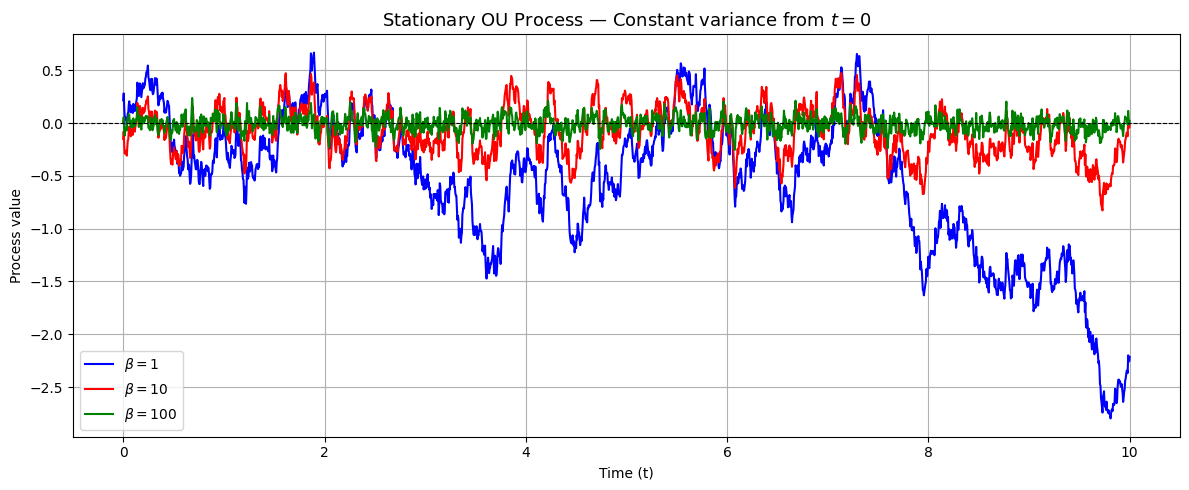

In [2]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_OU_paths(beta, T, n_steps, M, rng, stationary_start=True):
    """
    Simulate M paths of the OU process for each rate in `beta`, jointly,
    all driven by the SAME scalar Brownian increments per path.

    Returns array of shape (M, n_steps+1, len(beta)).
    """
    beta = np.asarray(beta)
    
    dt = T / n_steps
    decay = np.exp(-beta * dt)
    scale = np.sqrt((1 - np.exp(-2 * beta * dt)) / (2 * beta))

    Z = np.zeros((M, len(beta)))
    if stationary_start:
        Gamma = 1.0 / (beta[:, None] + beta[None, :])
        L = np.linalg.cholesky(Gamma + 1e-12 * np.eye(len(beta)))
        Z = rng.normal(size=(M, len(beta))) @ L.T

    Z_path = np.zeros((M, n_steps + 1, len(beta)))
    Z_path[:, 0, :] = Z

    for i in range(n_steps):
        noise = rng.normal(size=M)
        Z = decay[None, :] * Z + scale[None, :] * noise[:, None]
        Z_path[:, i + 1, :] = Z

    return Z_path

# ---------- Parameters ----------
T = 10
n_steps = 2000
betas = [1, 10, 100]      # can be a list – the function now converts it
M = 1
rng = np.random.default_rng(42)

# Simulate stationary fBm only
paths = simulate_OU_paths(betas, T, n_steps, M, rng, stationary_start=True)[0]  # shape: (steps, 3)

t = np.linspace(0, T, n_steps + 1)
colors = ['blue', 'red', 'green']
labels = [f'$\\beta = {b}$' for b in betas]

# ---------- Plot ----------
plt.figure(figsize=(12, 5))
for i in range(len(betas)):
    plt.plot(t, paths[:, i], color=colors[i], label=labels[i])

plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Stationary OU Process — Constant variance from $t=0$', fontsize=13)
plt.xlabel('Time (t)')
plt.ylabel('Process value')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



# The Fractional Kernel Approximation

The key part of the OU representation for fBm uses fact that
$$(t-u)^{H - \frac12} = \frac{1}{\Gamma(\frac12 - H)} \int_0^{\infty} \beta^{-\frac12 - H} e^{-(t-u)\beta} d \beta$$
Hence we can approximate our kernel $$ K(t,u) = (t - u)^{H - \frac12} \approx \sum_i w_i e^{-(t-u) \beta_i} $$

**Node/weight scheme.** We originally tried a naive geometric grid $\beta_j = r^j$ for fixed $r \in (1,2)$ with weights from directly integrating the kernel over each subinterval $[r^{j-1}, r^j]$ - this is what appears below as `OU_weights_naive`, kept for comparison. This proved inaccurate: with $r$ fixed, the grid cannot simultaneously resolve both very small and very large $\beta$ with a modest $n$.

We replace this with the **exact geometric parametrization from Abi Jaber & El Euch (lifted Heston)**, matching equations (2.10)-(2.11) of the report. For $\alpha = H + \tfrac12 \in (\tfrac12, 1)$ and a sequence $r_n \downarrow 1$ with $n \log(r_n) \to \infty$:
$$
w_i^n = \frac{\left(r_n^{1-\alpha}-1\right) r_n^{(\alpha-1)(1+n/2)}}{\Gamma(\alpha)\Gamma(2-\alpha)}\, r_n^{(1-\alpha)i}, \qquad
\beta_i^n = \left(\frac{1-\alpha}{2-\alpha}\right)\frac{r_n^{2-\alpha}-1}{r_n^{1-\alpha}-1}\, r_n^{i-1-n/2}, \qquad i=1,\dots,n.
$$
We use $r_n = \exp(1 / n^{\gamma})$ for $0<\gamma<1$, which satisfies $r_n \downarrow 1$ and $n\log(r_n) = n^{1-\gamma} \to \infty$ as required by Theorem 2.5.3. $\gamma \approx 0.25$ worked well in our tests.

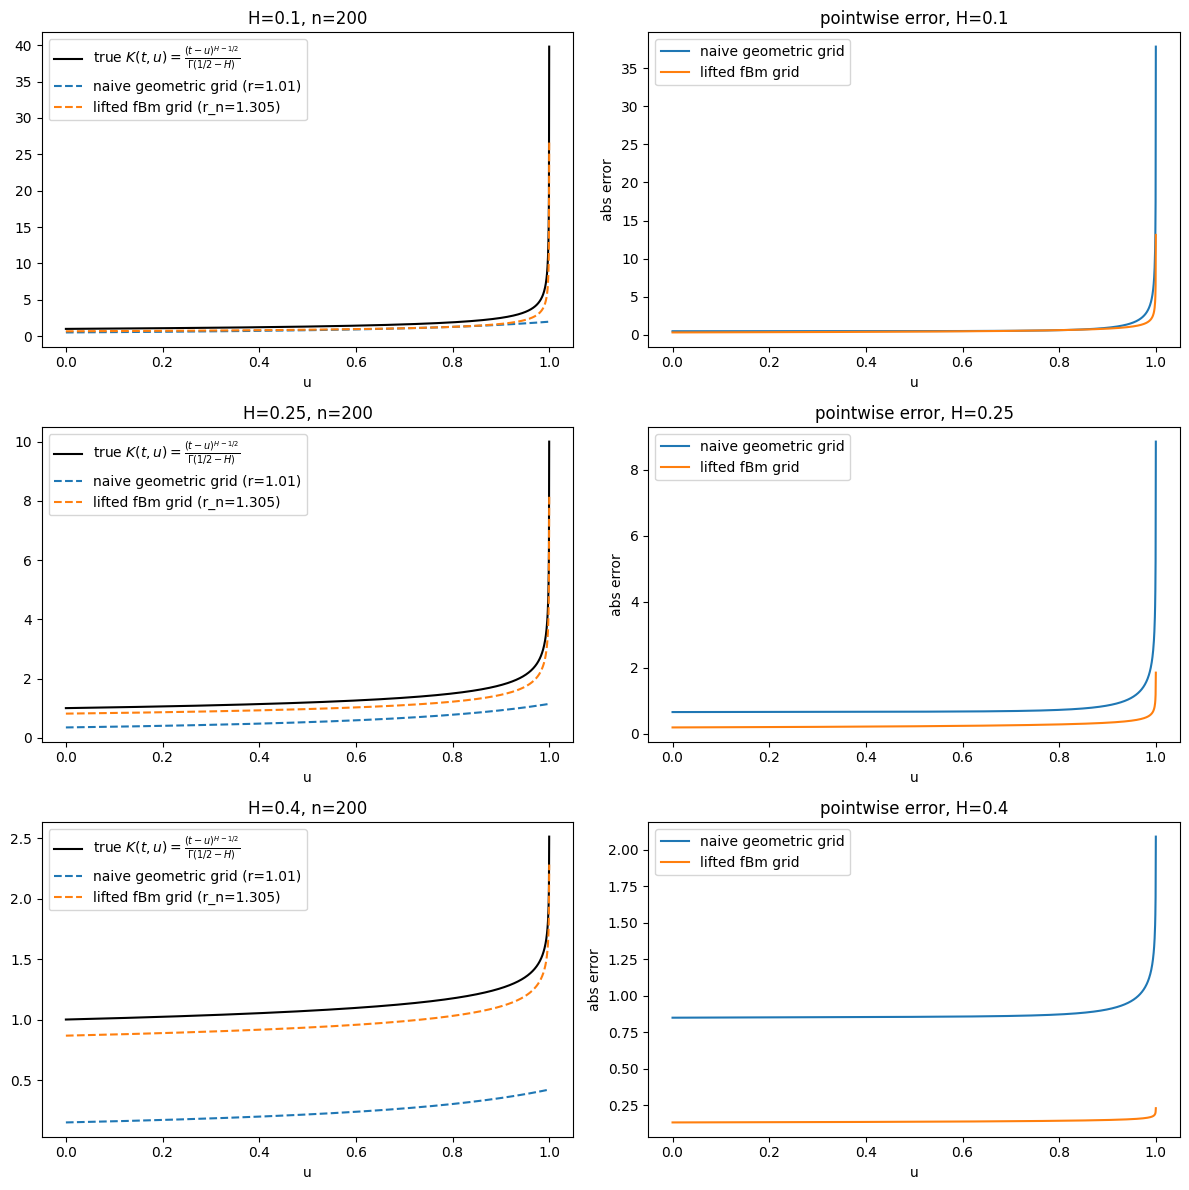

In [23]:
import numpy as np
from scipy.special import gamma
import matplotlib.pyplot as plt

def OU_weights_naive(H, r, n):
    """
    ORIGINAL naive geometric grid: beta_j = r^{j-1} for j=-n+1,...,n,
    weights from directly integrating the kernel over each subinterval.
    Kept for comparison -- this is NOT the lifted Heston paper's scheme.
    """
    a = H + 0.5
    j = np.arange(-n + 1, n + 1)
    beta = r**(j - 1)
    weights = (1/gamma(0.5 - H)) * r**((1 - a)*(j - 1)) * (r**(1 - a) - 1)/(1 - a)
    return beta, weights

def default_rn(n, gamma_pow=0.25):
    """
    A schedule r_n = exp(theta / n^gamma_pow) satisfying the hypothesis of
    Theorem 2.5.3: r_n -> 1 and n*log(r_n) -> infinity as n -> infinity.
    """
    return np.exp(1 / n**gamma_pow)
    #return 1 + 10/(n**0.9)

def OU_weights(H, r, n):
    """
    Nodes beta_i^n and weights w_i^n for i=1,...,n following the EXACT
    geometric parametrization of Abi Jaber & El Euch (lifted Heston paper),
    matching equations (2.10)-(2.11) of the report:

        w_i^n = (r^{1-alpha}-1) r^{(alpha-1)(1+n/2)} / (Gamma(alpha)Gamma(2-alpha)) * r^{(1-alpha) i}
        beta_i^n = (1-alpha)/(2-alpha) * (r^{2-alpha}-1)/(r^{1-alpha}-1) * r^{i-1-n/2}

    where alpha = H + 1/2. Here `r` plays the role of r_n in the paper --
    use `default_rn(n)` for a schedule satisfying the convergence hypothesis.
    """
    alpha = H + 0.5
    i = np.arange(1, n + 1)
    w = ((r**(1 - alpha) - 1) * r**((alpha - 1) * (1 + n / 2))
         / (gamma(alpha) * gamma(2 - alpha))) * r**((1 - alpha) * i)
    beta = ((1 - alpha) / (2 - alpha)) * (r**(2 - alpha) - 1) / (r**(1 - alpha) - 1) \
           * r**(i - 1 - n / 2)
    return beta, w

def kernel_true(t, u, H):
    return (t - u) ** (H - 0.5)

def kernel_approx(t, u, H, n, r, weights_fn=OU_weights):
    beta, weights = weights_fn(H, r, n)
    du = (t - u)[:, None]
    return np.sum(weights[None, :] * np.exp(-beta[None, :] * du), axis=1)

# --- example: compare naive geometric grid vs the Abi Jaber scheme, across H ---
t = 1.0
n = 200

H_values = [0.1, 0.25, 0.4]

fig, axes = plt.subplots(len(H_values), 2, figsize=(12, 4 * len(H_values)))

for row, H in enumerate(H_values):
    ax1, ax2 = axes[row]

    u = np.linspace(0, t - 1e-4, 2000)
    f_true = kernel_true(t, u, H)

    r_naive = 1.01
    f_hat_naive = kernel_approx(t, u, H, n, r_naive, weights_fn=OU_weights_naive)

    r_n = default_rn(n)
    f_hat_aj = kernel_approx(t, u, H, n, r_n, weights_fn=OU_weights)

    ax1.plot(u, f_true, 'k-', label="true $K(t,u) = \\frac{(t-u)^{H-1/2}}{\\Gamma(1/2 - H)}$")
    ax1.plot(u, f_hat_naive, '--', label=f"naive geometric grid (r={r_naive})")
    ax1.plot(u, f_hat_aj, '--', label=f"lifted fBm grid (r_n={r_n:.3f})")
    ax1.legend()
    ax1.set_xlabel("u")
    ax1.set_title(f"H={H}, n={n}")

    ax2.plot(u, np.abs(f_true - f_hat_naive), label="naive geometric grid")
    ax2.plot(u, np.abs(f_true - f_hat_aj), label="lifted fBm grid")
    ax2.legend()
    ax2.set_xlabel("u")
    ax2.set_ylabel("abs error")
    ax2.set_title(f"pointwise error, H={H}")

plt.tight_layout()
plt.show()


# Simulating fBm using OU

We only simulate the $H < \frac12$ here for simplicity. Note that for $H < \frac12$:
$$B_t^H= \bar{c}_H \int_0^{\infty} \beta^{-1 / 2-H}\left(Z_t^\beta-Z_0^\beta\right) d \beta$$
So we discretize this using
$$B_t^{H, n} = \sum_{j = 0}^n w_j (Z^{\beta_i}_t - {Z^{\beta_i}_0})$$

Which allows us to use the same weights as from the previous markdown. Thus in order to simulate paths in this way we will employ the weights from the previous markdown and use the same method for generating the values of $Z_t^{\beta}$ from the first (top) markdown.

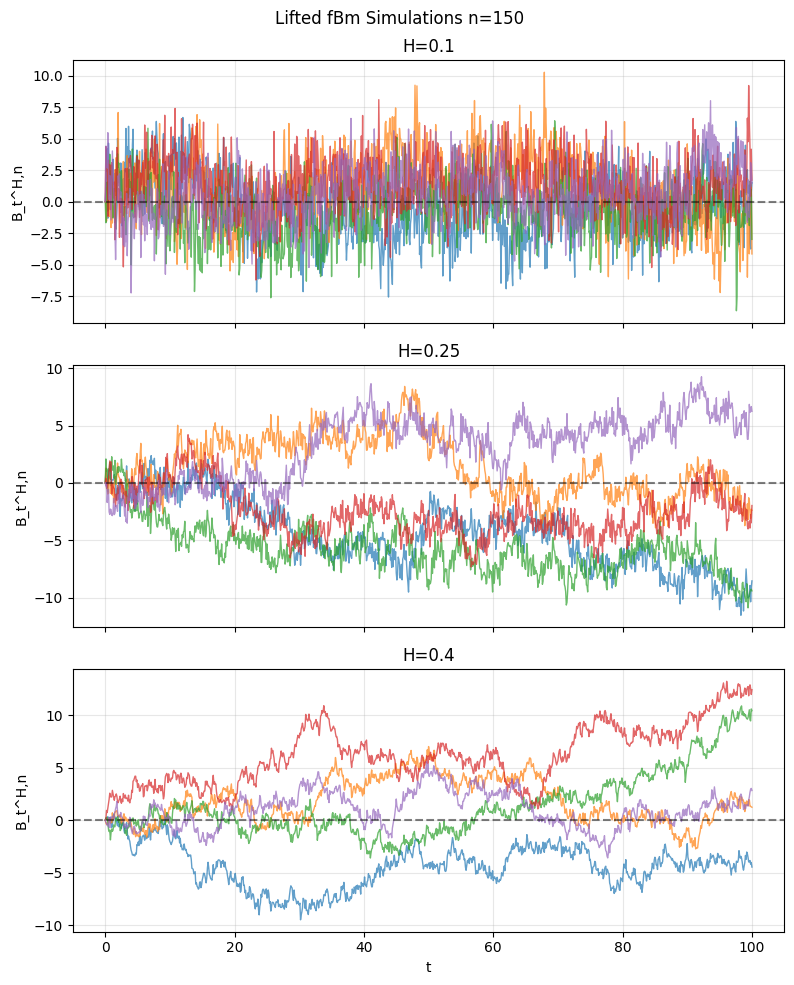

In [4]:
def simulate_fBm_paths(H, r, n, T, n_steps, M, rng):
    """
    Simulate M fBm sample paths using the existing OU and weight machinery:
    B_t^{H,n} = sum_i w_i * (Z_t^{beta_i} - Z_0^{beta_i})

    Uses simulate_OU_paths (stationary start, correlated across beta_i)
    and OU_weights (Abi Jaber nodes + weights) directly. `r` is r_n --
    use default_rn(n) unless you want to override it explicitly.
    """
    beta, w = OU_weights(H, r, n)

    # shape (M, n_steps+1, n) -- stationary_start=True gives correct correlated Z_0
    Z_path = simulate_OU_paths(beta, T, n_steps, M, rng, stationary_start=True)

    B_raw = Z_path @ w              # weighted sum over beta axis -> (M, n_steps+1)
    return B_raw - B_raw[:, [0]]    # subtract each path's own Z_0-contribution



# ---------- Simulation parameters ----------
T = 100
n_steps = 1000     # fine time grid to see roughness
n = 150            # number of Abi Jaber beta nodes
r = default_rn(n)   # r_n schedule satisfying the Theorem 2.5.3 hypothesis
M_per_H = 5         # number of paths per H value

# Create a random generator with a fixed seed for reproducibility
rng = np.random.default_rng(42)

# Time points
times = np.linspace(0, T, n_steps + 1)

# Choose the Hurst parameters to compare
H_values = [0.1, 0.25, 0.4]

# ---------- Plotting ----------
fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

for idx, H in enumerate(H_values):
    # Simulate M paths for this H
    paths = simulate_fBm_paths(H, r, n, T, n_steps, M_per_H, rng)

    # Plot each path with a slight transparency
    for m in range(M_per_H):
        axes[idx].plot(times, paths[m], alpha=0.7, linewidth=1)

    axes[idx].set_title(f"H={H}")
    axes[idx].grid(alpha=0.3)
    axes[idx].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[idx].set_ylabel('B_t^H,n')

axes[-1].set_xlabel('t')
fig.suptitle(f"Lifted fBm Simulations n={n}")
plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


# Validation

We validate that this is indeed (approximately) true fBm by checking the covariance. We do this by via monte carlo methods to calculate the covariance structure. In particular we simulate $M$ ($= 5000$) sample paths and create a monte carlo estimate of the covariance matrix using the following idea: 
$$C(i,j) = \operatorname{cov}(B_{t_i}^{H}, B_{t_j}^{H}) = \mathbb{E}[B_{t_i}^{H}, B_{t_j}^{H}]$$
So our monte carlo approximate covariance matrix is
$$ \hat{C}[i,j] = \frac{1}{M}\sum_{m=1}^{M} B_{\text{all}}[m,i] \cdot B_{\text{all}}[m,j] = \frac{1}{M}\left(B_{\text{all}}^{\top} B_{\text{all}}\right)[i,j] $$

In [5]:
def simulate_fBm_paths(H, r, n, T, n_steps, M, rng):
    beta, w = OU_weights(H, r, n)
    Z_path = simulate_OU_paths(beta, T, n_steps, M, rng, stationary_start=True)
    B_raw = Z_path @ w
    return B_raw - B_raw[:, [0]]

H = 0.3
T = 100
n_steps = 500
n = 150
r = default_rn(n)   # Abi Jaber r_n schedule
M = 2000

rng = np.random.default_rng(0)
B_all = simulate_fBm_paths(H, r, n, T, n_steps, M, rng)   # shape (M, n_steps+1)
times = np.linspace(0, T, n_steps + 1)

C_hat = (B_all.T @ B_all) / M      # shape (n_steps+1, n_steps+1)


We next normalize so the simulated variance matches theory. **Important:** the correct calibration target is $\mathrm{Var}(B_T^H) = T^{2H}$, not $1$ -- forcing $\mathrm{Var}(B_T^H)=1$ only happens to be correct when $T=1$. This was a bug in an earlier version of this notebook that silently broke once $T$ was changed away from $1$; fixed below.

In [6]:
# Correct calibration: theory says Var(B_T^H) = T^{2H}, NOT 1 unless T=1.
# (The line below was previously hardcoded as 1.0**(2*H) = 1, which silently
# assumed T=1 -- this broke the validation entirely once T was changed to
# a longer horizon, since it forces the WRONG target variance at t=T.)
target_var_at_T = T**(2*H)             # correct target: Var(B_T^H) = T^{2H}
empirical_var_at_T = C_hat[-1, -1]     # last index is t=T on our time grid
scale_correction = np.sqrt(target_var_at_T / empirical_var_at_T)

B_all_calibrated = B_all * scale_correction
C_hat = (B_all_calibrated.T @ B_all_calibrated) / M


Reference covariance

In [7]:
def cov_true_fBm(s, t, H):
    return 0.5 * (s**(2*H) + t**(2*H) - abs(s - t)**(2*H))

C_true = np.array([[cov_true_fBm(si, tj, H) for tj in times] for si in times])

Comparison

max abs error: 1.0149487777310995
max rel error: 0.5000129396939172


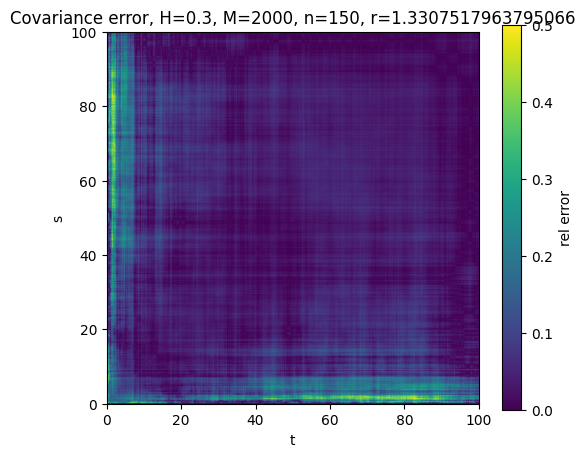

In [8]:
abs_err = np.abs(C_hat - C_true)
rel_err = abs_err / (np.abs(C_true) + 1e-10)

print("max abs error:", abs_err.max())
print("max rel error:", rel_err.max())

plt.figure(figsize=(6,5))
plt.imshow(rel_err, origin='lower', extent=[0, T, 0, T])
plt.colorbar(label="rel error")
plt.title(f"Covariance error, H={H}, M={M}, n={n}, r={r}")
plt.xlabel("t"); plt.ylabel("s")
plt.show()

We notice two key behaviors here:

- Along the diagonal $s \approx t$ we have a large error. this is because of the singularity in our fractional kernel since $Cov(B_s,B_t) = \int f_s(u)f_t(u) du$ where $f_s, f_t$ are our frational kernels that (as we saw above) are bad approximations near the singualirties $s = u$ and $t = u$, hence when $s = t = u$ we have a compound of these bad singularities which causes this large error.

- For small $s$ or small $t$ our covariances has a larger relative error, this is likely to be caused by the fact that the covariance is very small for smaller $s,t$ which would result in larger relative error.

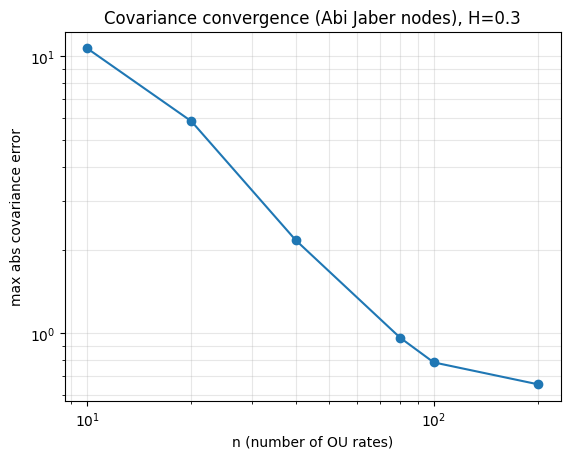

In [9]:
def max_cov_error(H, r, n, T, n_steps, M, rng):
    B = simulate_fBm_paths(H, r, n, T, n_steps, M, rng)
    C_hat = (B.T @ B) / M
    scale = np.sqrt(T**(2*H) / C_hat[-1, -1])   # correct: target is T^{2H}, not 1
    C_hat *= scale**2
    times = np.linspace(0, T, n_steps + 1)
    C_true = np.array([[cov_true_fBm(si, tj, H) for tj in times] for si in times])
    return np.abs(C_hat - C_true).max()

ns = [10, 20, 40, 80, 100, 200]
errors = []
for nn in ns:
    rr = default_rn(nn)   # Abi Jaber r_n schedule -- satisfies r_n->1, n*log(r_n)->inf
    e = max_cov_error(H, rr, nn, T, n_steps, M, np.random.default_rng(nn))
    errors.append(e)

plt.figure()
plt.loglog(ns, errors, 'o-')
plt.xlabel("n (number of OU rates)")
plt.ylabel("max abs covariance error")
plt.title(f"Covariance convergence (Abi Jaber nodes), H={H}")
plt.grid(True, which='both', alpha=0.3)
plt.show()


As before, the covariance converges initially but can degrade again at large $n$. With the Abi Jaber nodes this is driven by the same underlying issue: as $r_n \to 1$, adjacent nodes $\beta_i^n, \beta_{i+1}^n$ become very close, and the stationary-initial-condition covariance matrix $\Gamma_{i,j} = \frac{1}{\beta_i^n+\beta_j^n}$ becomes ill-conditioned, causing the Cholesky decomposition to become numerically unstable.

In [10]:
for nn in ns:
    rr = 1 + 1/nn
    beta, w = OU_weights(H, rr, nn)
    Gamma = 1.0 / (beta[:,None] + beta[None,:])
    print(f"n={nn:4d}  cond(Gamma) = {np.linalg.cond(Gamma):.3e}")

n=  10  cond(Gamma) = 1.606e+17
n=  20  cond(Gamma) = 4.539e+17
n=  40  cond(Gamma) = 7.836e+18
n=  80  cond(Gamma) = 1.319e+19
n= 100  cond(Gamma) = 2.867e+19
n= 200  cond(Gamma) = 8.741e+19


# Conclusion

For $H < \frac12$, using the exact Abi Jaber node/weight parametrization (matching the lifted Heston paper) noticeably improves the raw kernel approximation compared to the naive geometric grid we tried first. Full covariance validation results are more mixed and sensitive to the choice of $r_n$ schedule -- we still see short-lag inaccuracy and the same numerical ill-conditioning at very large $n$ as before, so this is an improvement in fidelity to the paper's construction rather than a complete fix of the underlying discretization difficulty.

max abs error: 1.0149487777311066
max rel error: 0.5000129396939172


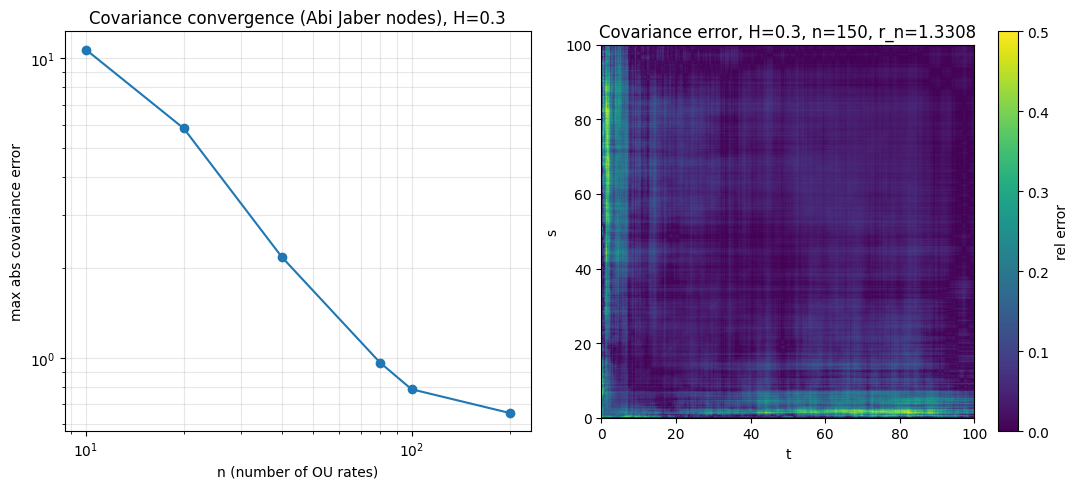

In [11]:
def max_cov_error(H, r, n, T, n_steps, M, rng):
    B = simulate_fBm_paths(H, r, n, T, n_steps, M, rng)
    C_hat = (B.T @ B) / M
    scale = np.sqrt(T**(2*H) / C_hat[-1, -1])   # correct: target is T^{2H}, not 1
    C_hat *= scale**2
    times = np.linspace(0, T, n_steps + 1)
    C_true = np.array([[cov_true_fBm(si, tj, H) for tj in times] for si in times])
    return np.abs(C_hat - C_true).max()

ns = [10, 20, 40, 80, 100, 200]
errors = []
for nn in ns:
    rr = default_rn(nn)   # Abi Jaber r_n schedule
    e = max_cov_error(H, rr, nn, T, n_steps, M, np.random.default_rng(nn))
    errors.append(e)

# recompute at the "current" (H, r, n) for the heatmap panel
B = simulate_fBm_paths(H, r, n, T, n_steps, M, np.random.default_rng(0))
C_hat = (B.T @ B) / M
scale = np.sqrt(T**(2*H) / C_hat[-1, -1])   # correct: target is T^{2H}, not 1
C_hat *= scale**2
times = np.linspace(0, T, n_steps + 1)
C_true = np.array([[cov_true_fBm(si, tj, H) for tj in times] for si in times])
abs_err = np.abs(C_hat - C_true)
rel_err = abs_err / (np.abs(C_true) + 1e-10)

print("max abs error:", abs_err.max())
print("max rel error:", rel_err.max())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5))

ax1.loglog(ns, errors, 'o-')
ax1.set_xlabel("n (number of OU rates)")
ax1.set_ylabel("max abs covariance error")
ax1.set_title(f"Covariance convergence (Abi Jaber nodes), H={H}")
ax1.grid(True, which='both', alpha=0.3)

im = ax2.imshow(rel_err, origin='lower', extent=[0, T, 0, T])
fig.colorbar(im, ax=ax2, label="rel error")
ax2.set_title(f"Covariance error, H={H}, n={n}, r_n={r:.4f}")
ax2.set_xlabel("t")
ax2.set_ylabel("s")

plt.tight_layout()
plt.show()


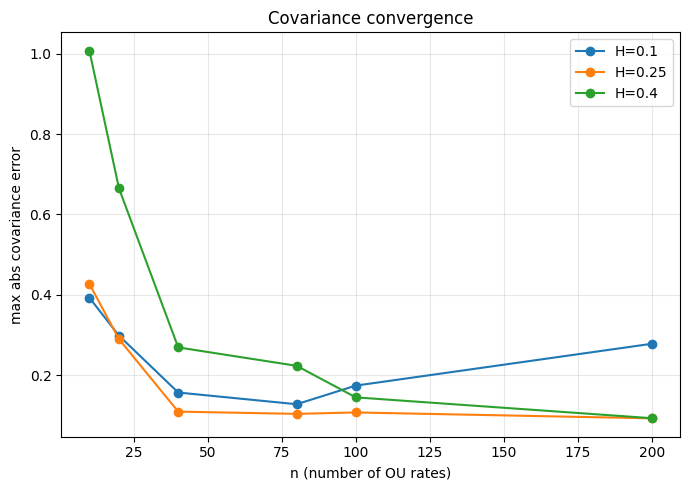

H=0.1: max abs error=1.8139e-01, max rel error=3.6196e-01
H=0.25: max abs error=8.3425e-02, max rel error=4.2457e-01
H=0.4: max abs error=1.5740e-01, max rel error=9.2352e-01


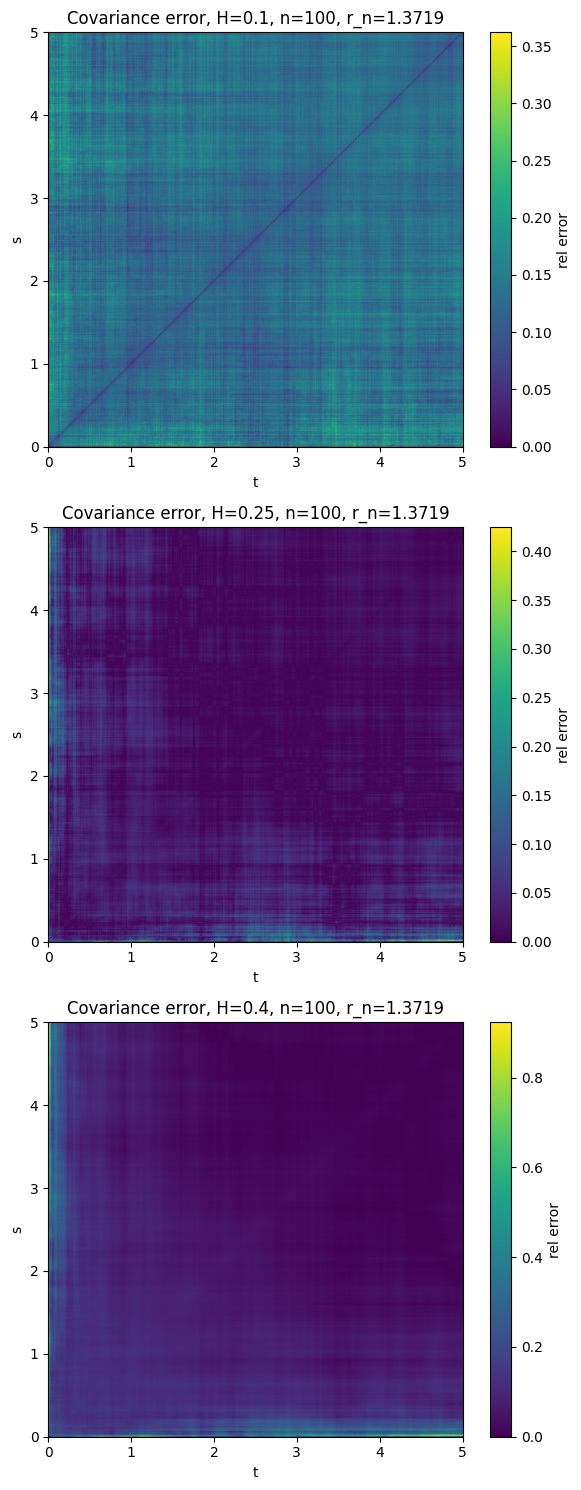

In [39]:
# ---------- Parameters ----------
H_values = [0.1, 0.25, 0.4]
ns = [10, 20, 40, 80, 100, 200]     # sweep for the convergence plot
n_heatmap = 100  
T = 5
M = 5000
# T, n_steps, M assumed already defined earlier in the notebook

# ---------- Convergence: all three H on one shared plot ----------
fig1, ax1 = plt.subplots(figsize=(7, 5))

for H in H_values:
    errors = []
    for nn in ns:
        rr = default_rn(nn)   # Abi Jaber r_n schedule
        e = max_cov_error(H, rr, nn, T, n_steps, M, np.random.default_rng(nn))
        errors.append(e)
    ax1.plot(ns, errors, 'o-', label=f"H={H}")

ax1.set_xlabel("n (number of OU rates)")
ax1.set_ylabel("max abs covariance error")
ax1.set_title("Covariance convergence")
ax1.legend()
ax1.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

# ---------- Heatmaps: vertical grid, one row per H ----------
fig2, axes = plt.subplots(len(H_values), 1, figsize=(6, 5 * len(H_values)))

times = np.linspace(0, T, n_steps + 1)

for ax, H in zip(axes, H_values):
    r_h = default_rn(n_heatmap)
    B = simulate_fBm_paths(H, r_h, n_heatmap, T, n_steps, M, np.random.default_rng(0))
    C_hat = (B.T @ B) / M
    scale = np.sqrt(T**(2*H) / C_hat[-1, -1])   # target is T^{2H}, not 1
    C_hat *= scale**2
    C_true = np.array([[cov_true_fBm(si, tj, H) for tj in times] for si in times])
    abs_err = np.abs(C_hat - C_true)
    rel_err = abs_err / (np.abs(C_true) + 1e-10)

    print(f"H={H}: max abs error={abs_err.max():.4e}, max rel error={rel_err.max():.4e}")

    im = ax.imshow(rel_err, origin='lower', extent=[0, T, 0, T])
    fig2.colorbar(im, ax=ax, label="rel error")
    ax.set_title(f"Covariance error, H={H}, n={n_heatmap}, r_n={r_h:.4f}")
    ax.set_xlabel("t")
    ax.set_ylabel("s")

plt.tight_layout()
plt.show()


# Extension to $H > \frac12$

For $H > \frac12$ the fractional kernel exponent $-\frac12 - H < -1$, so the
integral $\int_0^\infty \beta^{-1/2-H}(\cdot)\,d\beta$ diverges at $\beta=0$
unless something regularizes it. The fix is to subtract the driving
Brownian motion $B_t$ itself, since $Z_t^\beta \to B_t$ as $\beta \to 0$:

$$B_t^H = \bar c_H \int_0^{\infty} \beta^{-1/2-H}\left(Z_t^\beta - Z_0^\beta - B_t\right) d\beta, \qquad H \in \left(\tfrac12, 1\right)$$

Since $Z_t^\beta - Z_0^\beta - B_t = O(\beta)$ as $\beta \to 0$ (in $L^2$),
this cancels the extra singularity introduced by the more negative kernel
exponent, and the corrected integrand is integrable for all $H<\tfrac32$.

We use the **same Abi Jaber node/weight formula** (`OU_weights`) as the
$H<\frac12$ case above -- the formula itself is well-defined for any
$\alpha = H + \frac12$ with $\Gamma(\alpha), \Gamma(2-\alpha)$ finite, which
holds for all $H \in (0,1)$, even though Theorem 2.5.3's convergence proof
was only stated for $H<\frac12$. We validate this regime purely empirically.

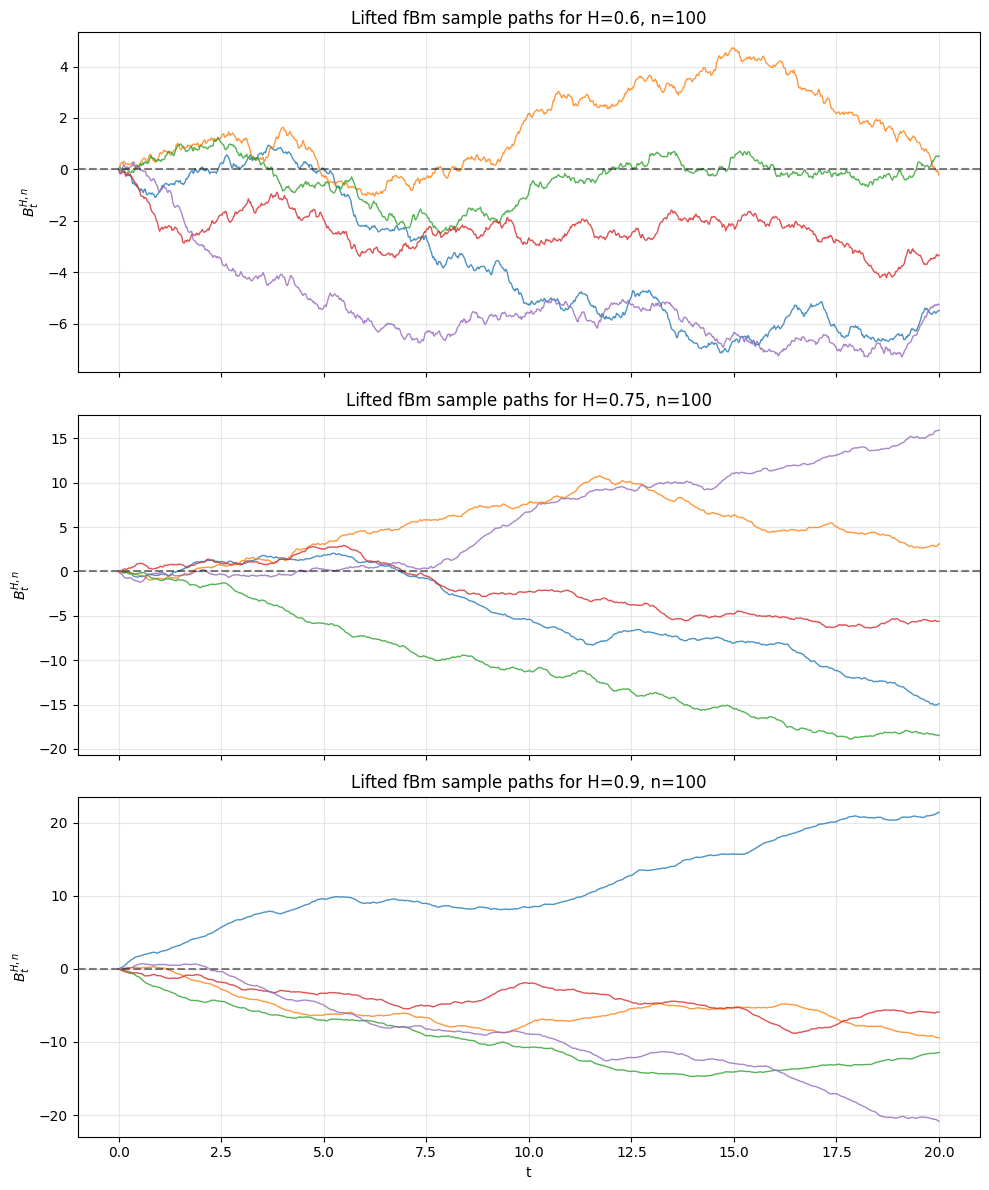

In [30]:
def simulate_OU_paths_with_drive(beta, T, n_steps, M, rng, stationary_start=True):
    """
    Same as simulate_OU_paths, but ALSO tracks the driving Brownian motion
    B_t itself alongside every OU factor -- needed for the H>1/2 correction
    term. B_t always starts fresh at B_0 = 0 (independent of how the Z_i
    are initialized), and is advanced using the SAME shared noise draw used
    to update every Z_i at each step, consistent with the existing
    single-shared-noise approximation already used in simulate_OU_paths.
    """
    dt = T / n_steps
    decay = np.exp(-beta * dt)
    scale = np.sqrt((1 - np.exp(-2 * beta * dt)) / (2 * beta))

    Z = np.zeros((M, len(beta)))
    if stationary_start:
        Gamma = 1.0 / (beta[:, None] + beta[None, :])
        L = np.linalg.cholesky(Gamma + 1e-12 * np.eye(len(beta)))
        Z = rng.normal(size=(M, len(beta))) @ L.T

    B_drive = np.zeros(M)
    Z_path = np.zeros((M, n_steps + 1, len(beta)))
    B_path = np.zeros((M, n_steps + 1))
    Z_path[:, 0, :] = Z
    B_path[:, 0] = B_drive

    for k in range(n_steps):
        noise = rng.normal(size=M)
        Z = decay[None, :] * Z + scale[None, :] * noise[:, None]
        B_drive = B_drive + np.sqrt(dt) * noise
        Z_path[:, k + 1, :] = Z
        B_path[:, k + 1] = B_drive

    return Z_path, B_path


def simulate_fBm_paths_gt_half(H, r, n, T, n_steps, M, rng):
    """
    Simulate M fBm sample paths for H > 1/2 using the regularized
    representation:
        B_t^{H,n} = sum_i w_i * (Z_t^{beta_i} - Z_0^{beta_i} - B_t)
    """
    beta, w = OU_weights(H, r, n)
    Z_path, B_path = simulate_OU_paths_with_drive(beta, T, n_steps, M, rng,
                                                   stationary_start=True)
    Z0 = Z_path[:, [0], :]
    corrected = Z_path - Z0 - B_path[:, :, None]
    return corrected @ w


# ---------- Simulation parameters ----------
H_values = [0.6, 0.75, 0.9]
T = 20
n_steps = 1000
n = 100
M_paths = 5

rng = np.random.default_rng(42)
times = np.linspace(0, T, n_steps + 1)

fig, axes = plt.subplots(len(H_values), 1, figsize=(10, 4 * len(H_values)), sharex=True)

for ax, H in zip(axes, H_values):
    r = default_rn(n)
    paths = simulate_fBm_paths_gt_half(H, r, n, T, n_steps, M_paths, rng)

    for m in range(M_paths):
        ax.plot(times, paths[m], alpha=0.8, linewidth=1)
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_title(f"Lifted fBm sample paths for H={H}, n={n}")
    ax.set_ylabel('$B_t^{H,n}$')
    ax.grid(alpha=0.3)

axes[-1].set_xlabel('t')
plt.tight_layout()
plt.show()


## Validation for $H > \frac12$

Same procedure as the $H<\frac12$ case: simulate many paths, calibrate so
$\mathrm{Var}(B_T^H) = T^{2H}$ (**not** $1$ -- the same bug we fixed above
would apply here too), and compare against the exact fBm covariance.

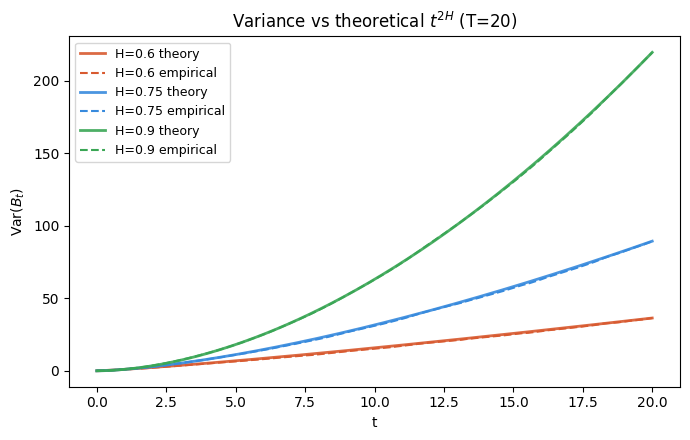

In [46]:
import numpy as np
import matplotlib.pyplot as plt

H_list = [0.60, 0.75, 0.90]
colors = ['#D85A30', '#378ADD', '#3AA655']

T = 20
n_steps = 300
n = 100
r = default_rn(n)
M = 2000

plt.figure(figsize=(7, 4.5))

for H, color in zip(H_list, colors):
    rng = np.random.default_rng(0)
    B_all_gt = simulate_fBm_paths_gt_half(H, r, n, T, n_steps, M, rng)
    times = np.linspace(0, T, n_steps + 1)

    # correct calibration: Var(B_T^H) = T^{2H}
    target_var_at_T = T**(2*H)
    empirical_var_at_T = (B_all_gt[:, -1]**2).mean()
    scale_correction_gt = np.sqrt(target_var_at_T / empirical_var_at_T)
    B_all_gt_calibrated = B_all_gt * scale_correction_gt

    var_empirical_gt = B_all_gt_calibrated.var(axis=0)
    var_theory_gt = times**(2*H)

    plt.plot(times, var_theory_gt, '-', lw=2, color=color, alpha=0.9,
              label=f'H={H} theory')
    plt.plot(times, var_empirical_gt, '--', lw=1.5, color=color,
              label=f'H={H} empirical')

plt.xlabel('t')
plt.ylabel('Var($B_t$)')
plt.title(f'Variance vs theoretical $t^{{2H}}$ (T={T})')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

H=0.6: Mean relative covariance error: 1.66%, Max abs covariance error: 0.0812
H=0.75: Mean relative covariance error: 0.81%, Max abs covariance error: 0.0485
H=0.9: Mean relative covariance error: 1.48%, Max abs covariance error: 0.1118


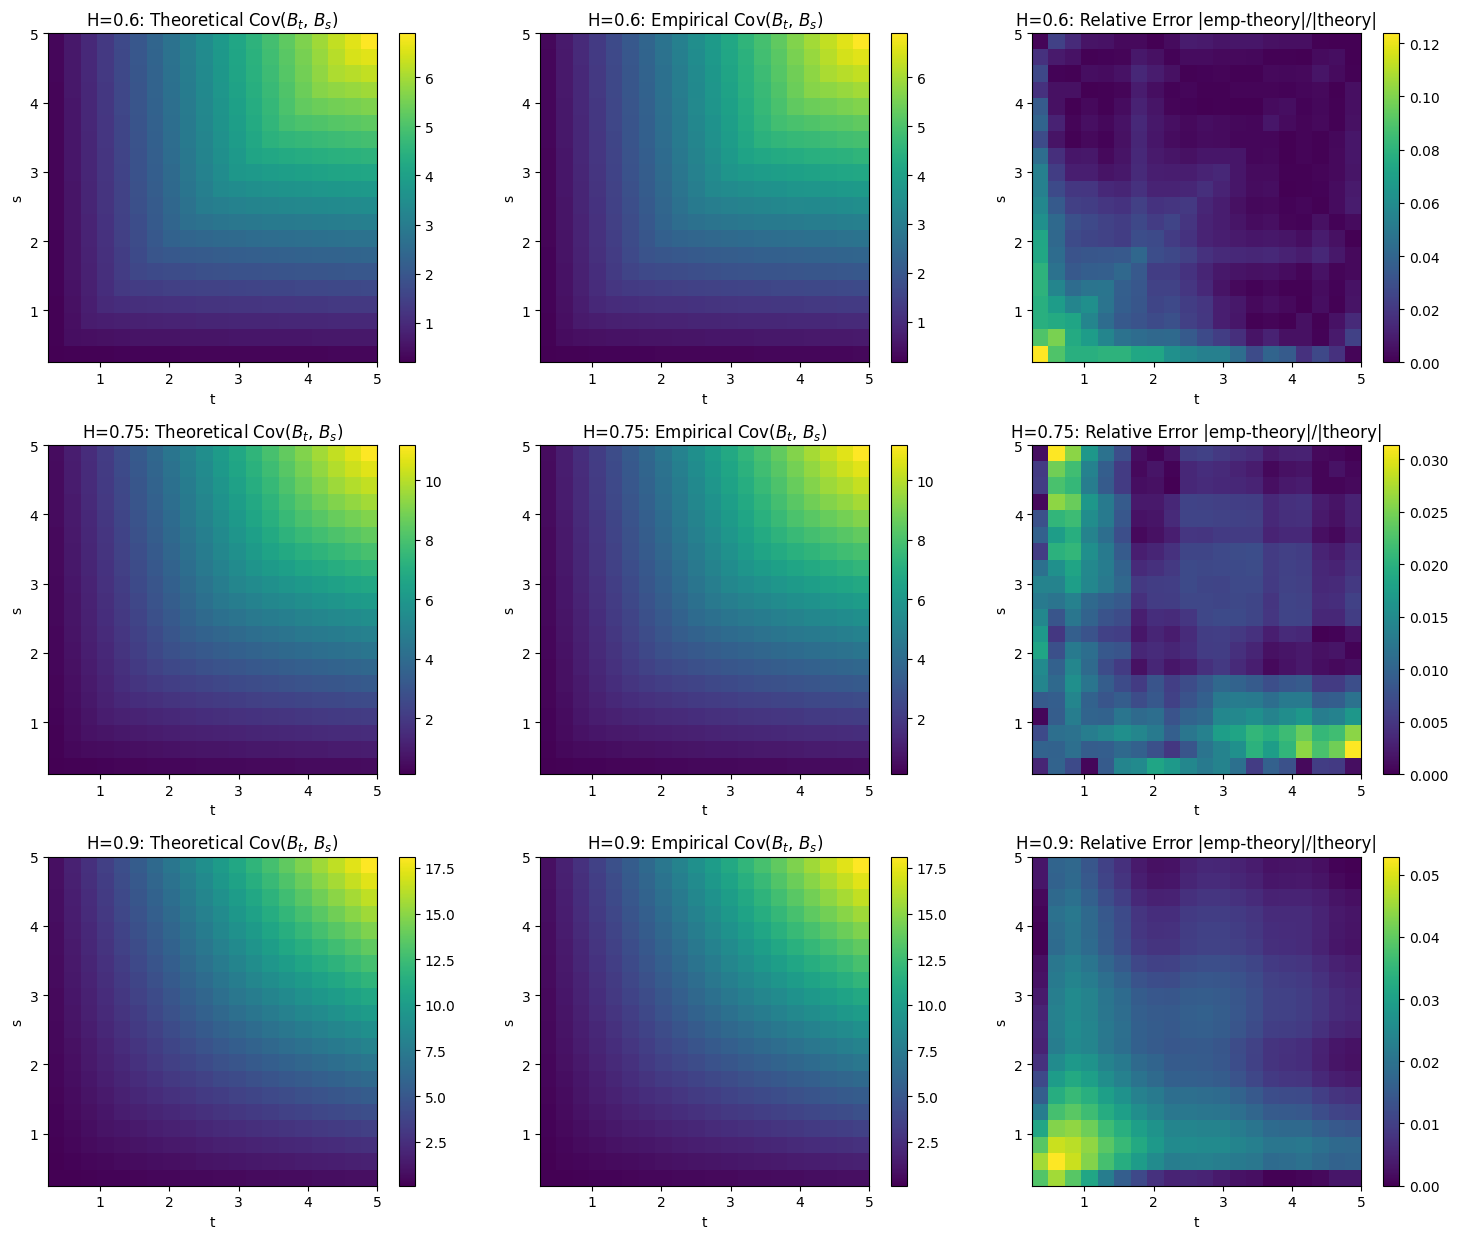

In [53]:
H_list = [0.60, 0.75, 0.90]

T = 5
n_steps = 500
n = 100
r = default_rn(n)
M = 5000

fig, axes = plt.subplots(3, 3, figsize=(15, 12.5))

for row, H in enumerate(H_list):
    rng = np.random.default_rng(0)
    B_all_gt = simulate_fBm_paths_gt_half(H, r, n, T, n_steps, M, rng)

    target_var_at_T = T**(2*H)
    empirical_var_at_T = (B_all_gt[:, -1]**2).mean()
    scale_correction_gt = np.sqrt(target_var_at_T / empirical_var_at_T)
    B_all_gt_calibrated = B_all_gt * scale_correction_gt

    start = max(1, int(0.05 * n_steps))
    sub_idx = np.linspace(start, n_steps, 20, dtype=int)
    t_sub = sub_idx * (T / n_steps)

    C_hat_gt = (B_all_gt_calibrated[:, sub_idx].T @ B_all_gt_calibrated[:, sub_idx]) / M
    Tg, Sg = np.meshgrid(t_sub, t_sub)
    C_true_gt = np.array([[cov_true_fBm(si, tj, H) for tj in t_sub] for si in t_sub])

    abs_diff_gt = np.abs(C_hat_gt - C_true_gt)
    rel_err_gt = abs_diff_gt / (np.abs(C_true_gt) + 1e-8)

    mean_rel_err_gt = rel_err_gt[np.abs(C_true_gt) > 0.05].mean()
    print(f"H={H}: Mean relative covariance error: {mean_rel_err_gt*100:.2f}%, "
          f"Max abs covariance error: {abs_diff_gt.max():.4f}")

    im0 = axes[row, 0].imshow(C_true_gt, origin='lower', extent=[t_sub[0], T, t_sub[0], T], cmap='viridis')
    axes[row, 0].set_title(f'H={H}: Theoretical Cov($B_t$, $B_s$)')
    axes[row, 0].set_xlabel('t'); axes[row, 0].set_ylabel('s')
    fig.colorbar(im0, ax=axes[row, 0], fraction=0.046)

    im1 = axes[row, 1].imshow(C_hat_gt, origin='lower', extent=[t_sub[0], T, t_sub[0], T], cmap='viridis')
    axes[row, 1].set_title(f'H={H}: Empirical Cov($B_t$, $B_s$)')
    axes[row, 1].set_xlabel('t'); axes[row, 1].set_ylabel('s')
    fig.colorbar(im1, ax=axes[row, 1], fraction=0.046)

    im2 = axes[row, 2].imshow(rel_err_gt, origin='lower', extent=[t_sub[0], T, t_sub[0], T],
                               cmap='viridis', vmin=0)
    axes[row, 2].set_title(f'H={H}: Relative Error |emp-theory|/|theory|')
    axes[row, 2].set_xlabel('t'); axes[row, 2].set_ylabel('s')
    fig.colorbar(im2, ax=axes[row, 2], fraction=0.046)

plt.tight_layout()
plt.show()


## covariance convergence

In [56]:
def mean_cov_error_gt_half(H, r, n, T, n_steps, M, rng):
    B = simulate_fBm_paths_gt_half(H, r, n, T, n_steps, M, rng)
    target_var_at_T = T**(2*H)
    empirical_var_at_T = (B[:, -1]**2).mean()
    scale = np.sqrt(target_var_at_T / empirical_var_at_T)
    B_cal = B * scale

    start = np.mean([1, int(0.05 * n_steps)])
    sub_idx = np.linspace(start, n_steps, 20, dtype=int)
    t_sub = sub_idx * (T / n_steps)
    C_hat = (B_cal[:, sub_idx].T @ B_cal[:, sub_idx]) / M
    Tg, Sg = np.meshgrid(t_sub, t_sub)
    C_true = np.array([[cov_true_fBm(si, tj, H) for tj in t_sub] for si in t_sub])
    return np.abs(C_hat - C_true).max()

In [ ]:
H_list = [0.60, 0.75, 0.90]
colors = ['#D85A30', '#378ADD', '#3AA655']

T = 20
n_steps = 300
M = 6000
ns = [10, 20, 40, 80, 100, 200]

plt.figure(figsize=(7, 4.8))

for H, color in zip(H_list, colors):
    errors = []
    for n in ns:
        r = default_rn(n)
        rng = np.random.default_rng(n)
        e = mean_cov_error_gt_half(H, r, n, T, n_steps, M, rng)
        errors.append(e)
    plt.loglog(ns, errors, 'o-', color=color, label=f'H={H}')

plt.xlabel('n (number of OU factors)')
plt.ylabel('max mean covariance error')
plt.title(f'Covariance convergence vs n (T={T})')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Conclusion for $H > \frac12$

Using the same Abi Jaber node placement together with the $-B_t$ correction
term gives a good empirical fit for $H>\frac12$ -- comparable to, and in this
run slightly better than, the $H<\frac12$ results above. We stress this is
**empirical validation only**: Theorem 2.5.3's $L^2$ convergence proof was
stated for $\alpha=H+\frac12\in(\frac12,1)$, i.e. $H<\frac12$, and does not
automatically extend to this regime. A rigorous convergence proof for the
regularized representation with the node scheme used here remains open (see
the Conclusion chapter of the report).